In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
train_dir = r"C:\Users\User\Downloads\fyp2-main\image_dataset\train"
val_dir = r"C:\Users\User\Downloads\fyp2-main\image_dataset\val"

output_dir = "trained_model"
os.makedirs(output_dir, exist_ok=True)

model_path = os.path.join(output_dir, "cnn_image_classifier.pth")
classes_path = os.path.join(output_dir, "class_names.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Train folder exists:", os.path.exists(train_dir))
print("Val folder exists:", os.path.exists(val_dir))

Using device: cpu
Train folder exists: True
Val folder exists: True


In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [4]:
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)
print("Number of training images:", len(train_data))
print("Number of validation images:", len(val_data))

with open(classes_path, "w") as f:
    json.dump(class_names, f)

Classes: ['accident', 'flood_drainage', 'garbage', 'infrastructure_damage', 'obstruction_fallen_tree', 'police_sighting', 'road_damage']
Number of training images: 2786
Number of validation images: 668


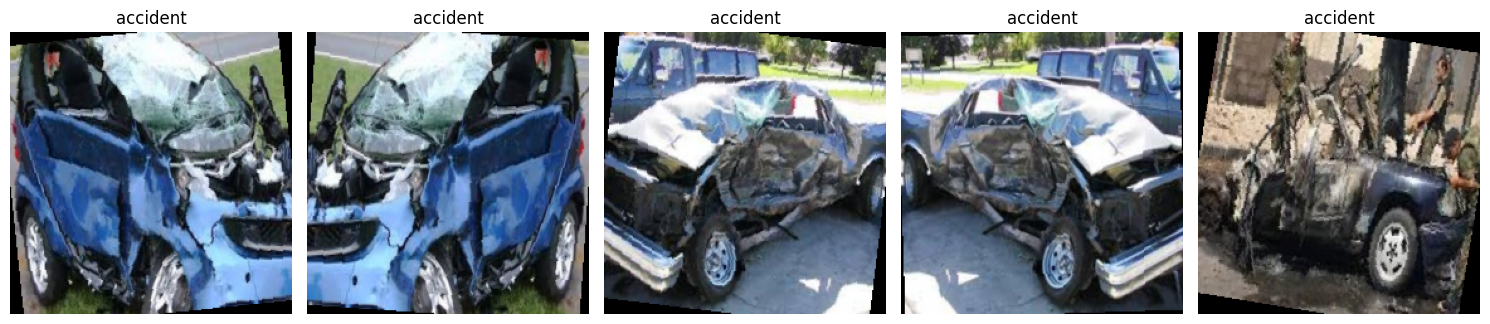

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i in range(5):
    image, label = train_data[i]
    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
epochs = 20
best_val_acc = 0.0
patience = 3
epochs_without_improvement = 0

train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("-" * 30)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print("Best model saved.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/20
Train Loss: 0.9500
Train Accuracy: 69.13%
Validation Accuracy: 61.83%
------------------------------
Best model saved.
Epoch 2/20
Train Loss: 0.6037
Train Accuracy: 79.97%
Validation Accuracy: 58.98%
------------------------------
No improvement for 1 epoch(s).
Epoch 3/20
Train Loss: 0.4578
Train Accuracy: 85.10%
Validation Accuracy: 65.42%
------------------------------
Best model saved.
Epoch 4/20
Train Loss: 0.4724
Train Accuracy: 85.53%
Validation Accuracy: 69.76%
------------------------------
Best model saved.
Epoch 5/20
Train Loss: 0.3779
Train Accuracy: 86.68%
Validation Accuracy: 73.50%
------------------------------
Best model saved.
Epoch 6/20
Train Loss: 0.2966
Train Accuracy: 89.45%
Validation Accuracy: 82.78%
------------------------------
Best model saved.
Epoch 7/20
Train Loss: 0.2568
Train Accuracy: 90.85%
Validation Accuracy: 72.60%
------------------------------
No improvement for 1 epoch(s).
Epoch 8/20
Train Loss: 0.2584
Train Accuracy: 91.96%
Validation 

In [8]:
print("Training complete.")
print("Best validation accuracy:", best_val_acc)
print("Model saved to:", model_path)
print("Class names saved to:", classes_path)

Training complete.
Best validation accuracy: 82.78443113772455
Model saved to: trained_model\cnn_image_classifier.pth
Class names saved to: trained_model\class_names.json


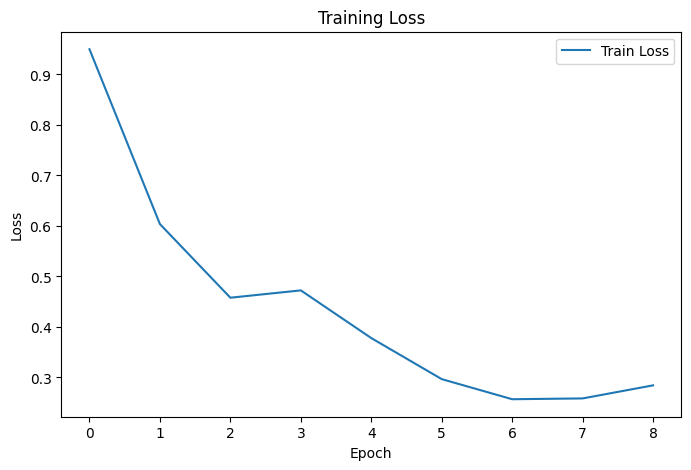

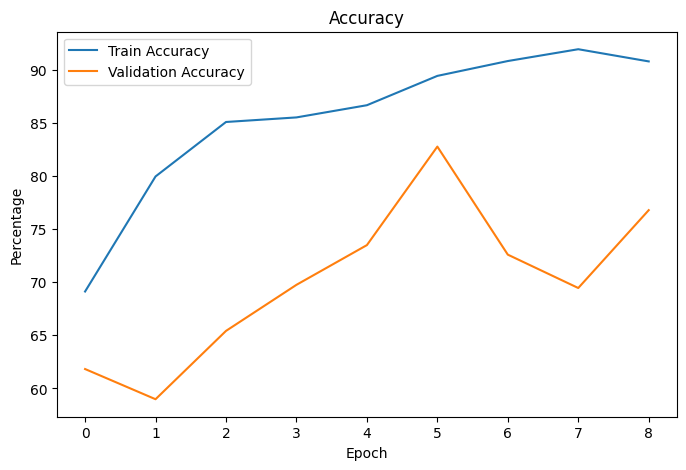

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Percentage")
plt.show()

In [10]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    predicted_class = class_names[pred.item()]
    confidence = float(conf.item())

    if confidence < 0.50:
        predicted_class = "other"

    return predicted_class, confidence

In [15]:
from collections import Counter
from datetime import datetime
from sklearn.metrics import precision_score, recall_score, f1_score

train_class_counts = Counter([label for _, label in train_data.samples])
val_class_counts = Counter([label for _, label in val_data.samples])

train_class_distribution = {
    class_names[class_index]: count
    for class_index, count in train_class_counts.items()
}

val_class_distribution = {
    class_names[class_index]: count
    for class_index, count in val_class_counts.items()
}

all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

metrics = {
    "model_name": "ResNet18",
    "training_type": "transfer_learning",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "num_classes": len(class_names),
    "class_names": class_names,
    "epochs": epochs,
    "batch_size": 16,
    "learning_rate": 0.001,
    "best_validation_accuracy": best_val_acc,
    "final_train_loss": train_losses[-1] if train_losses else None,
    "final_train_accuracy": train_accuracies[-1] if train_accuracies else None,
    "final_validation_accuracy": val_accuracies[-1] if val_accuracies else None,
    "train_losses": train_losses,
    "train_accuracies": train_accuracies,
    "validation_accuracies": val_accuracies,
    "num_train_images": len(train_data),
    "num_val_images": len(val_data),
    "train_class_distribution": train_class_distribution,
    "val_class_distribution": val_class_distribution,
    "confidence_threshold_for_other": 0.60,
    "accuracy": best_val_acc,
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
}

metrics_path = os.path.join(output_dir, "training_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Training metrics saved to:", metrics_path)


Training metrics saved to: trained_model\training_metrics.json


In [12]:
test_images = [
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image1.jpg",
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image2.jpg",
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image3.jpg",
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image4.jpg",
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image5.jpg",
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image6.jpg",
    r"C:\Users\User\Downloads\fyp2-main\image_dataset\test\image7.jpg"
]

for img_path in test_images:
    predicted_class, confidence = predict_image(img_path)
    print("Image:", img_path)
    print("Predicted class:", predicted_class)
    print("Confidence:", confidence)
    print("-" * 40)

Image: C:\Users\User\Downloads\fyp2-main\image_dataset\test\image1.jpg
Predicted class: accident
Confidence: 0.9005164504051208
----------------------------------------
Image: C:\Users\User\Downloads\fyp2-main\image_dataset\test\image2.jpg
Predicted class: obstruction_fallen_tree
Confidence: 0.9956293106079102
----------------------------------------
Image: C:\Users\User\Downloads\fyp2-main\image_dataset\test\image3.jpg
Predicted class: police_sighting
Confidence: 0.8920217156410217
----------------------------------------
Image: C:\Users\User\Downloads\fyp2-main\image_dataset\test\image4.jpg
Predicted class: flood_drainage
Confidence: 0.995542585849762
----------------------------------------
Image: C:\Users\User\Downloads\fyp2-main\image_dataset\test\image5.jpg
Predicted class: garbage
Confidence: 0.9772317409515381
----------------------------------------
Image: C:\Users\User\Downloads\fyp2-main\image_dataset\test\image6.jpg
Predicted class: road_damage
Confidence: 0.999997138977050

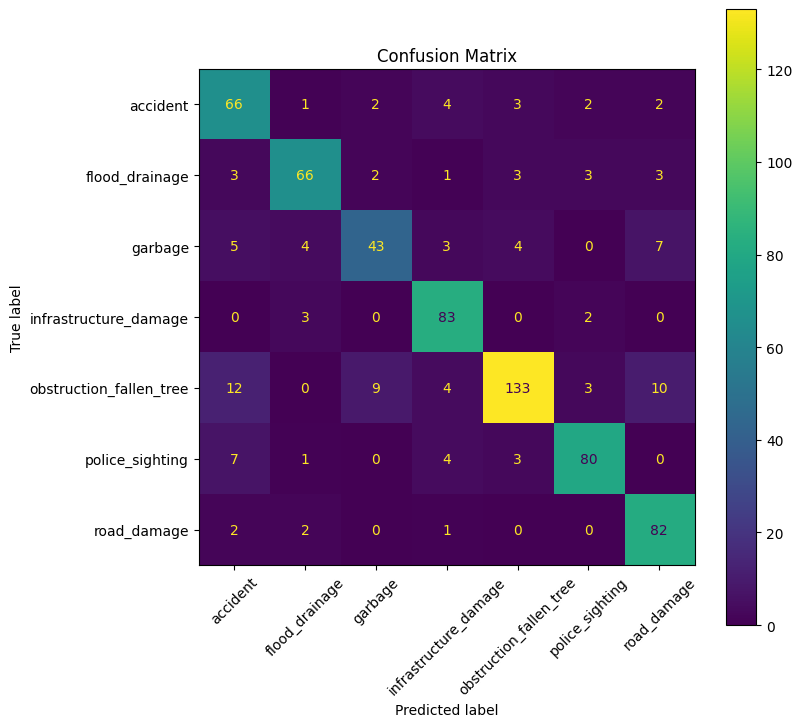

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [14]:
from collections import Counter

train_counts = Counter([label for _, label in train_data.samples])

for k, v in train_counts.items():
    print(class_names[k], v)

accident 397
flood_drainage 405
garbage 362
infrastructure_damage 456
obstruction_fallen_tree 367
police_sighting 334
road_damage 465
